<a href="https://colab.research.google.com/github/hihowareyou2008/ML-Projects/blob/main/BigMartStock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [ ]:
mart_data = pd.read_csv("/content/Train (1).csv")

In [ ]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
mart_data.shape

(8523, 12)

In [ ]:
mart_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [ ]:
mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
new_mart_data = mart_data.drop(['Item_Identifier', 'Item_Outlet_Sales', 'Item_Fat_Content',
                                'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'], axis=1)

In [ ]:
correlation = new_mart_data.corr()

<Axes: >

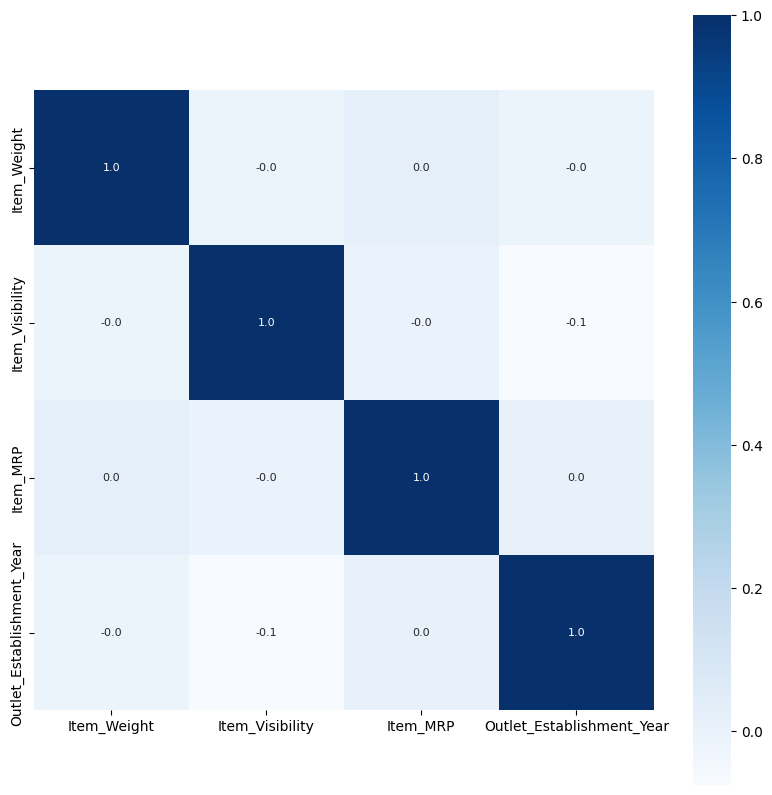

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [ ]:
mart_data['Item_Weight'].fillna(mart_data['Item_Weight'].mean(), inplace=True)

/tmp/ipython-input-346007548.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mart_data['Item_Weight'].fillna(mart_data['Item_Weight'].mean(), inplace=True)


In [ ]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
label_encode = LabelEncoder()

In [ ]:
Label_1 = label_encode.fit_transform(mart_data.Item_Identifier)
Label_2 = label_encode.fit_transform(mart_data.Item_Fat_Content)
Label_3 = label_encode.fit_transform(mart_data.Item_Type)
Label_4 = label_encode.fit_transform(mart_data.Outlet_Identifier)
Label_5 = label_encode.fit_transform(mart_data.Outlet_Size)
Label_6 = label_encode.fit_transform(mart_data.Outlet_Location_Type)
Label_7 = label_encode.fit_transform(mart_data.Outlet_Type)

In [ ]:
mart_data['Item_Identifier'] = Label_1
mart_data['Item_Fat_Content'] = Label_2
mart_data['Item_Type'] = Label_3
mart_data['Outlet_Identifier'] = Label_4
mart_data['Outlet_Size'] = Label_5
mart_data['Outlet_Location_Type'] = Label_6
mart_data['Outlet_Type'] = Label_7

In [ ]:
mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,1,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,2,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,1,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,2,0.000000,6,182.0950,0,1998,3,2,0,732.3800
4,1297,8.93,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [ ]:
X = mart_data.drop(columns='Item_Outlet_Sales')
Y = mart_data['Item_Outlet_Sales']

In [ ]:
print(X)
print(Y)

      Item_Identifier  Item_Weight  ...  Outlet_Location_Type  Outlet_Type
0                 156        9.300  ...                     0            1
1                   8        5.920  ...                     2            2
2                 662       17.500  ...                     0            1
3                1121       19.200  ...                     2            0
4                1297        8.930  ...                     2            1
...               ...          ...  ...                   ...          ...
8518              370        6.865  ...                     2            1
8519              897        8.380  ...                     1            1
8520             1357       10.600  ...                     1            1
8521              681        7.210  ...                     2            2
8522               50       14.800  ...                     0            1

[8523 rows x 11 columns]
0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4 

In [ ]:
X_test, X_train, Y_test, Y_train = train_test_split(X, Y, test_size=0.3, random_state=4)

In [ ]:
print(X_train)

      Item_Identifier  Item_Weight  ...  Outlet_Location_Type  Outlet_Type
4476              636    20.500000  ...                     2            1
4192              277    12.857645  ...                     0            0
355               446    19.250000  ...                     0            1
8433              627    11.800000  ...                     1            1
385               214    15.250000  ...                     1            1
...               ...          ...  ...                   ...          ...
2357               55    12.857645  ...                     2            3
8049               38    19.100000  ...                     2            1
2360              438    17.100000  ...                     0            1
2789               72    17.600000  ...                     1            1
8215             1228    12.857645  ...                     0            0

[2557 rows x 11 columns]


In [ ]:
print(Y_train)

4476    1797.6600
4192     265.6542
355     4093.3384
8433    1813.6392
385      610.5386
          ...    
2357    2439.4912
8049     731.0484
2360    1404.8380
2789    1644.5260
8215     387.4956
Name: Item_Outlet_Sales, Length: 2557, dtype: float64


In [ ]:
ran_reg_model = RandomForestRegressor()

In [ ]:
ran_reg_model.fit(X_train, Y_train)

RandomForestRegressor()

In [ ]:
training_data_prediction = ran_reg_model.predict(X_train)

In [ ]:
# R Squared Error (Training)
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R Squared Error: ", error_score)

R Squared Error:  0.9334510175251566


In [ ]:
testing_data_prediction = ran_reg_model.predict(X_test)

In [ ]:
# R Squared Error (Testing)
error_score_two = metrics.r2_score(Y_test, testing_data_prediction)
print("R Squared Error: ", error_score_two)

R Squared Error:  0.5568191481631617


In [ ]:
model = XGBRegressor()

In [ ]:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
train_data_pred = model.predict(X_train)

In [ ]:
print(train_data_pred)

[1496.4932   120.70311 3178.252   ... 2122.3662  1965.5645   464.1674 ]


In [ ]:
# R Squared Error (Training)
score_1 = metrics.r2_score(Y_train, train_data_pred)

# Mean Absolute Error (Training)
score_2 = metrics.mean_absolute_error(Y_train, train_data_pred)

print("R Squared Error: ", score_1)
print("Mean absolute Error", score_2)

R Squared Error:  0.9610045068796171
Mean absolute Error 229.84078619716496


In [ ]:
test_data_pred = model.predict(X_test)

In [ ]:
print(test_data_pred)

[4504.2295 1691.6555 3120.0261 ... 1426.3179 1157.7513 1339.86  ]


In [ ]:
# R Squared Error (Testing)
score_3 = metrics.r2_score(Y_test, test_data_pred)

# Mean Absolute Error (Testing)
score_4 = metrics.mean_absolute_error(Y_test, test_data_pred)

print("R Squared Error: ", score_3)
print("Mean absolute Error", score_4)

R Squared Error:  0.4897618340935709
Mean absolute Error 871.0651959376308
